# AI Job Salary Prediction — Baseline Supervised Learning Models

**Research Question:** How effectively can baseline supervised learning models predict AI job salaries?

**Target Variable:** `salary_usd` (continuous — regression task)

**Models Evaluated:**
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- K-Nearest Neighbors Regressor

**Expected Result:** Baseline models should achieve reasonable but not optimal performance, confirming that the dataset contains useful predictive patterns.

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('All libraries loaded successfully.')


All libraries loaded successfully.


## 2. Load Data

In [ ]:
# ── Update this path if the CSV lives elsewhere ──
DATA_PATH = '../data/ai_job_dataset1.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()


Shape: (15000, 20)


,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


## 3. Exploratory Data Analysis

In [ ]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics for Numeric Columns ===')
df.describe()


=== Data Types ===
job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
salary_local                int64
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object

=== Missing Values ===
job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
salary_local              0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_re

,salary_usd,salary_local,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000
mean,121991.938267,8.292366e+05,50.196667,6.365667,1500.852600,7.499540
std,63968.361846,3.425325e+06,40.844084,5.598551,574.724647,1.444202
min,16621.000000,1.662100e+04,0.000000,0.000000,500.000000,5.000000
25%,74978.500000,7.383075e+04,0.000000,2.000000,998.750000,6.300000
50%,107261.500000,1.090355e+05,50.000000,5.000000,1512.000000,7.500000
75%,155752.250000,1.673278e+05,100.000000,10.000000,1994.000000,8.800000
max,410273.000000,3.368541e+07,100.000000,19.000000,2499.000000,10.000000


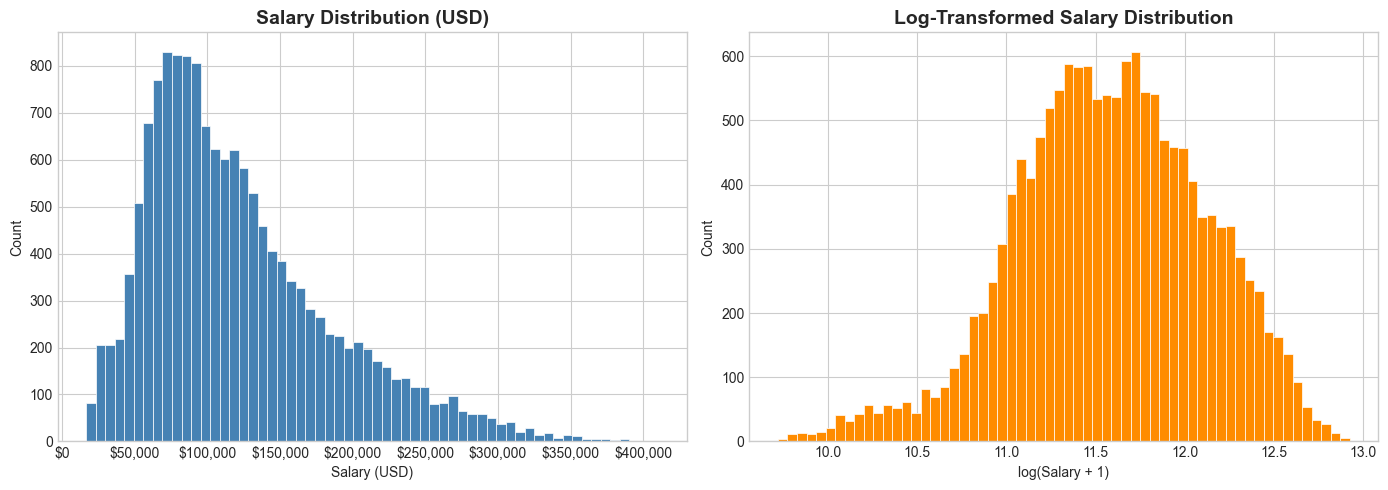

Salary range: $16,621 — $410,273
Mean:  $121,992 | Median: $107,262


In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['salary_usd'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Salary Distribution (USD)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].hist(np.log1p(df['salary_usd']), bins=60, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log-Transformed Salary Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Salary + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salary range: ${df["salary_usd"].min():,.0f} — ${df["salary_usd"].max():,.0f}')
print(f'Mean:  ${df["salary_usd"].mean():,.0f} | Median: ${df["salary_usd"].median():,.0f}')


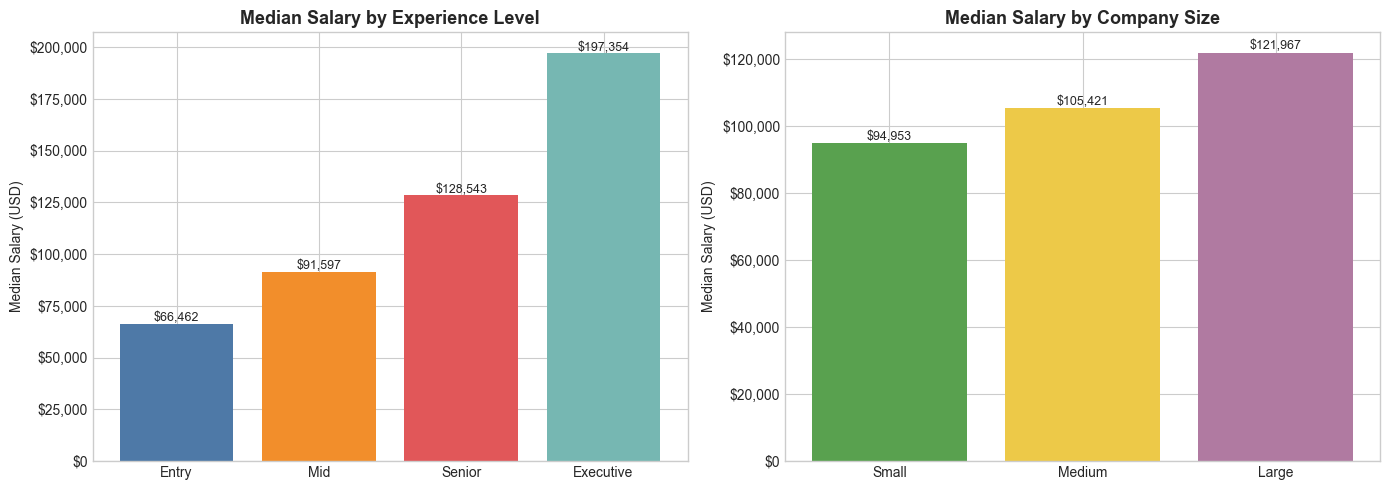

In [ ]:
# Salary by experience level
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

medians = df.groupby('experience_level')['salary_usd'].median().reindex(exp_order)
bars = axes[0].bar([exp_labels[e] for e in exp_order], medians.values, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'])
axes[0].set_title('Median Salary by Experience Level', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Median Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, medians.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f'${val:,.0f}', ha='center', fontsize=9)

# Salary by company size
size_order = ['S', 'M', 'L']
size_labels = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
medians2 = df.groupby('company_size')['salary_usd'].median().reindex(size_order)
bars2 = axes[1].bar([size_labels[s] for s in size_order], medians2.values, color=['#59a14f','#edc948','#b07aa1'])
axes[1].set_title('Median Salary by Company Size', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Median Salary (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars2, medians2.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f'${val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('salary_by_groups.png', dpi=150, bbox_inches='tight')
plt.show()


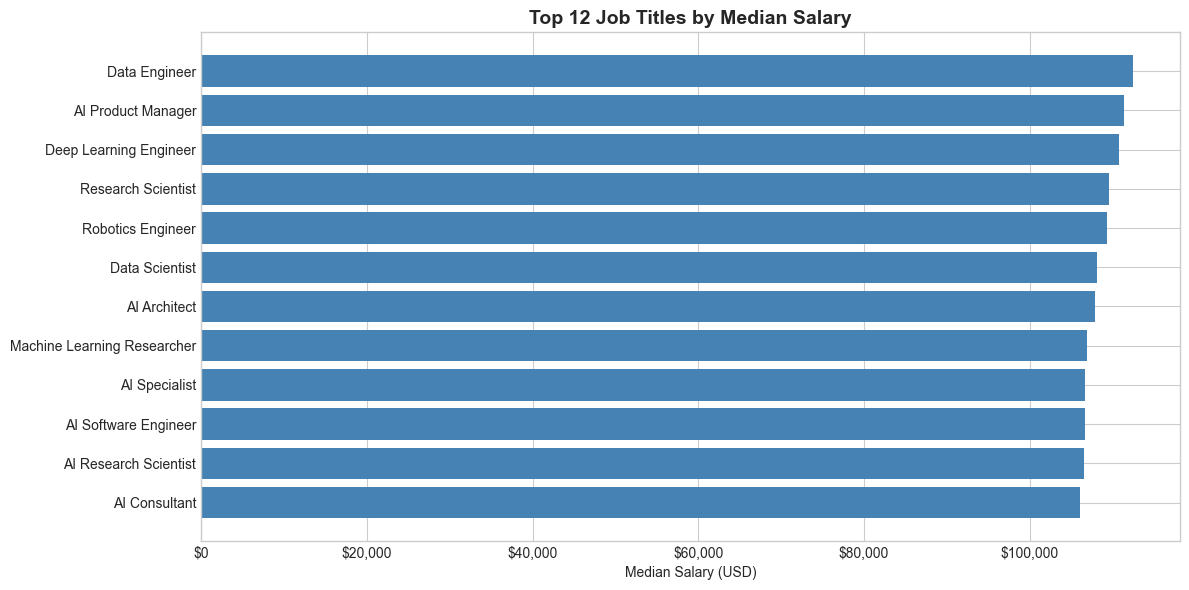

In [ ]:
# Top 12 job titles by median salary
top_titles = (df.groupby('job_title')['salary_usd']
               .median()
               .sort_values(ascending=False)
               .head(12))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_titles.index[::-1], top_titles.values[::-1], color='steelblue')
ax.set_title('Top 12 Job Titles by Median Salary', fontsize=14, fontweight='bold')
ax.set_xlabel('Median Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('top_titles_salary.png', dpi=150, bbox_inches='tight')
plt.show()


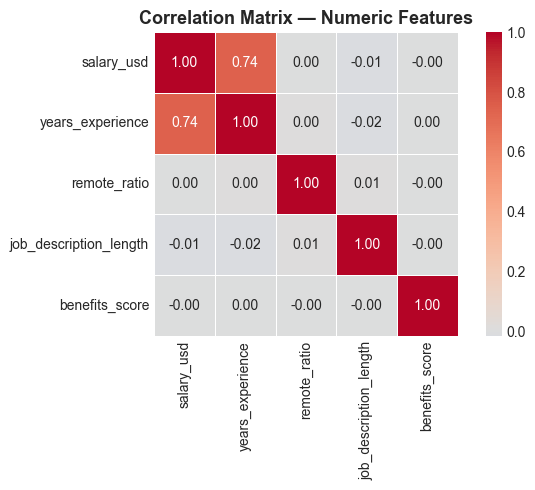

In [ ]:
# Correlation heatmap — numeric features
numeric_cols = ['salary_usd', 'years_experience', 'remote_ratio', 'job_description_length', 'benefits_score']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Feature Engineering & Preprocessing

In [ ]:
# ── Drop columns that leak target or are identifiers ──
# salary_local  → same info as salary_usd but in local currency (data leakage)
# salary_currency → proxy for location, partially redundant
# job_id        → identifier
# company_name  → too many categories, low signal vs noise at baseline
# posting_date / application_deadline → dates; could engineer but skip for baseline

DROP_COLS = ['job_id', 'salary_local', 'salary_currency',
             'company_name', 'posting_date', 'application_deadline']
df_model = df.drop(columns=DROP_COLS)

# ── Feature: number of required skills ──
df_model['num_skills'] = df_model['required_skills'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)
df_model = df_model.drop(columns=['required_skills'])

print('Remaining columns:', df_model.columns.tolist())
print('Shape:', df_model.shape)


Remaining columns: ['job_title', 'salary_usd', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'job_description_length', 'benefits_score', 'num_skills']
Shape: (15000, 14)


In [ ]:
# ── Encode categorical columns with Label Encoding ──
CAT_COLS = ['job_title', 'experience_level', 'employment_type',
            'company_location', 'company_size', 'employee_residence',
            'education_required', 'industry']

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

# ── Define features and target ──
TARGET = 'salary_usd'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Target: {TARGET}')


Features (13): ['job_title', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'job_description_length', 'benefits_score', 'num_skills']
Target: salary_usd


In [ ]:
# ── Train / Test split (80/20) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')


Training set:  12,000 rows
Test set:      3,000 rows


## 5. Baseline Model Training

Each model is wrapped in a `Pipeline` with `StandardScaler` so features are normalised before fitting — critical for KNN and Linear Regression.

In [ ]:
models = {
    'Linear Regression':      Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Decision Tree':          Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeRegressor(max_depth=8, random_state=SEED))]),
    'Random Forest':          Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1))]),
    'K-Nearest Neighbors':    Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=10, n_jobs=-1))]),
}

results = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae   = mean_absolute_error(y_test, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
    r2    = r2_score(y_test, y_pred)

    # 5-fold CV R² on training set
    cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'CV R²': cv_r2}
    print(f'{name:25s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:.4f} | CV R²: {cv_r2:.4f}')

results_df = pd.DataFrame(results).T.round(4)
print('\n=== Summary Table ===')
results_df


Linear Regression         | MAE: $    27,180 | RMSE: $    38,436 | R²: 0.6313 | CV R²: 0.6138
Decision Tree             | MAE: $    16,028 | RMSE: $    22,572 | R²: 0.8729 | CV R²: 0.8617
Random Forest             | MAE: $    15,572 | RMSE: $    21,609 | R²: 0.8835 | CV R²: 0.8781
K-Nearest Neighbors       | MAE: $    26,904 | RMSE: $    37,284 | R²: 0.6531 | CV R²: 0.6286

=== Summary Table ===


,MAE,RMSE,R²,CV R²
Linear Regression,27179.6331,38436.0807,0.6313,0.6138
Decision Tree,16028.3892,22571.8822,0.8729,0.8617
Random Forest,15571.7785,21608.7707,0.8835,0.8781
K-Nearest Neighbors,26904.0638,37284.1814,0.6531,0.6286


## 6. Results Visualisation

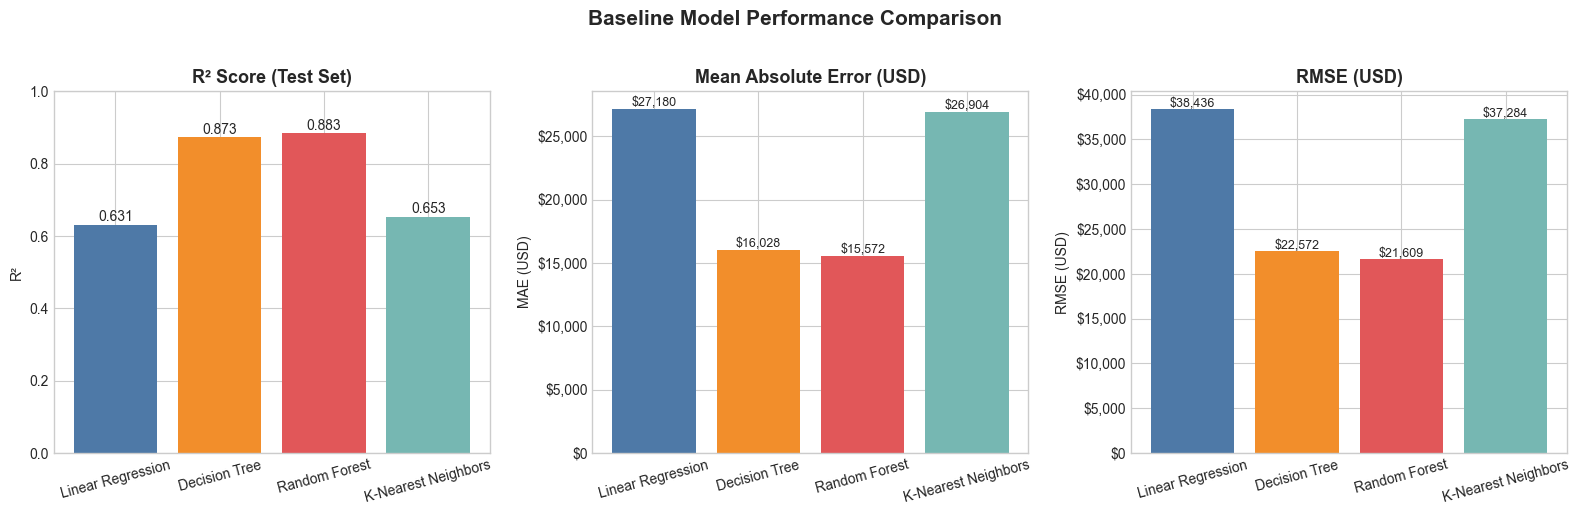

In [ ]:
# ── Bar chart: R² and CV R² comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
model_names = list(results.keys())

# R²
r2_vals = [results[m]['R²'] for m in model_names]
bars = axes[0].bar(model_names, r2_vals, color=colors)
axes[0].set_title('R² Score (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)

# MAE
mae_vals = [results[m]['MAE'] for m in model_names]
bars2 = axes[1].bar(model_names, mae_vals, color=colors)
axes[1].set_title('Mean Absolute Error (USD)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'${val:,.0f}', ha='center', fontsize=9)

# RMSE
rmse_vals = [results[m]['RMSE'] for m in model_names]
bars3 = axes[2].bar(model_names, rmse_vals, color=colors)
axes[2].set_title('RMSE (USD)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('RMSE (USD)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'${val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Baseline Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


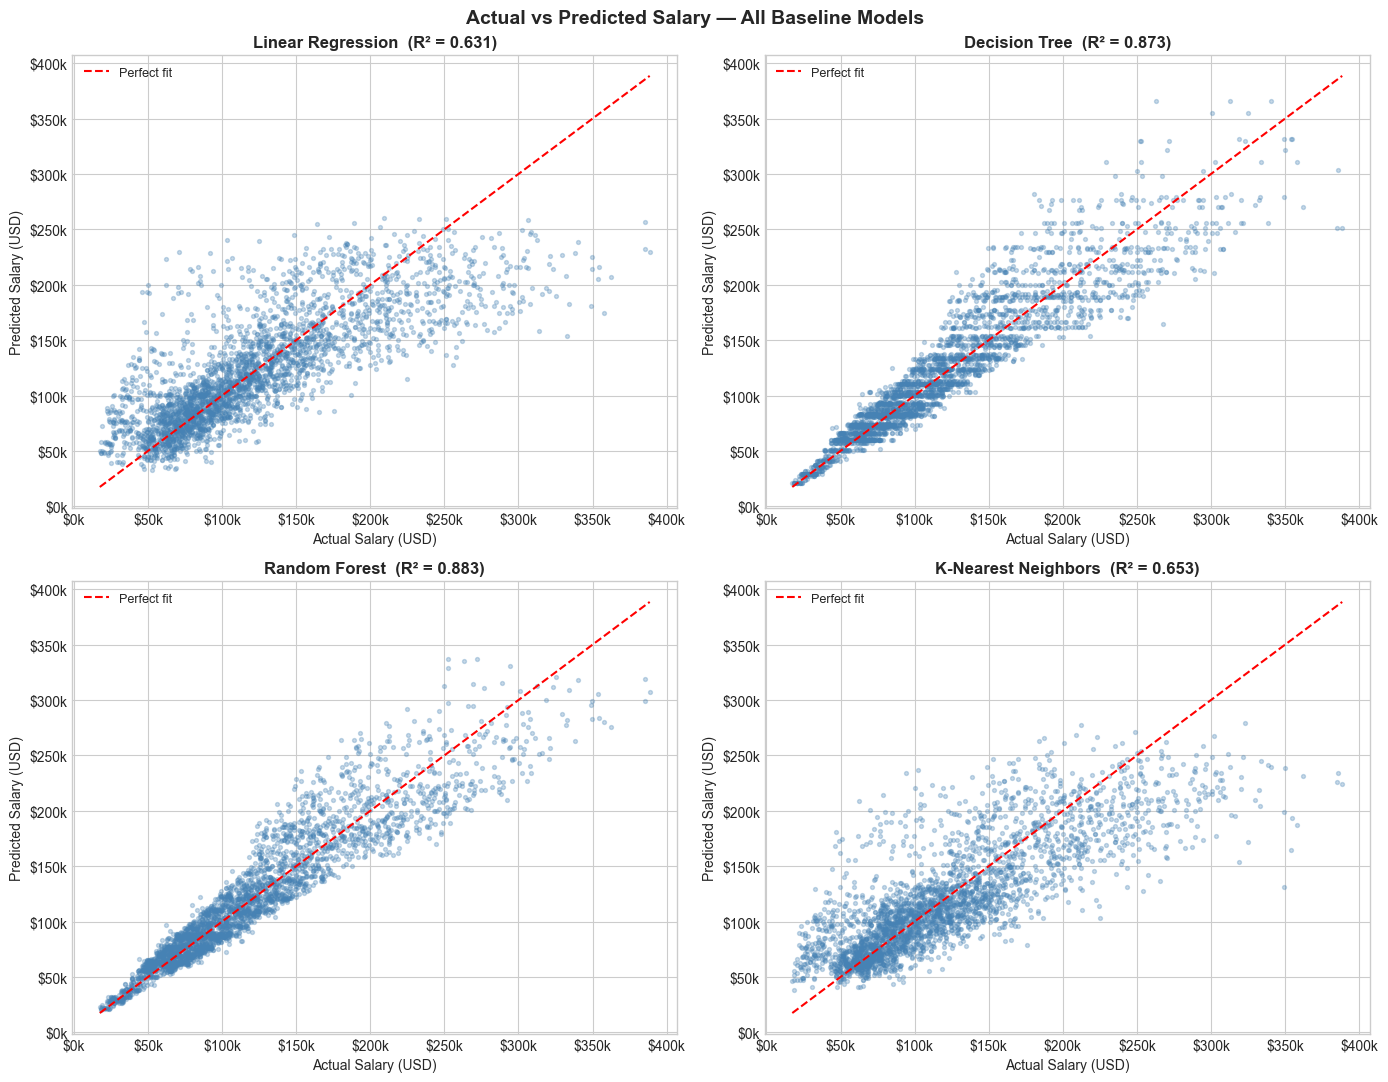

In [ ]:
# ── Actual vs Predicted plots for each model ──
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred = pipeline.predict(X_test)
    r2 = results[name]['R²']

    ax.scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue', rasterized=True)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'{name}  (R² = {r2:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Salary (USD)')
    ax.set_ylabel('Predicted Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Salary — All Baseline Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


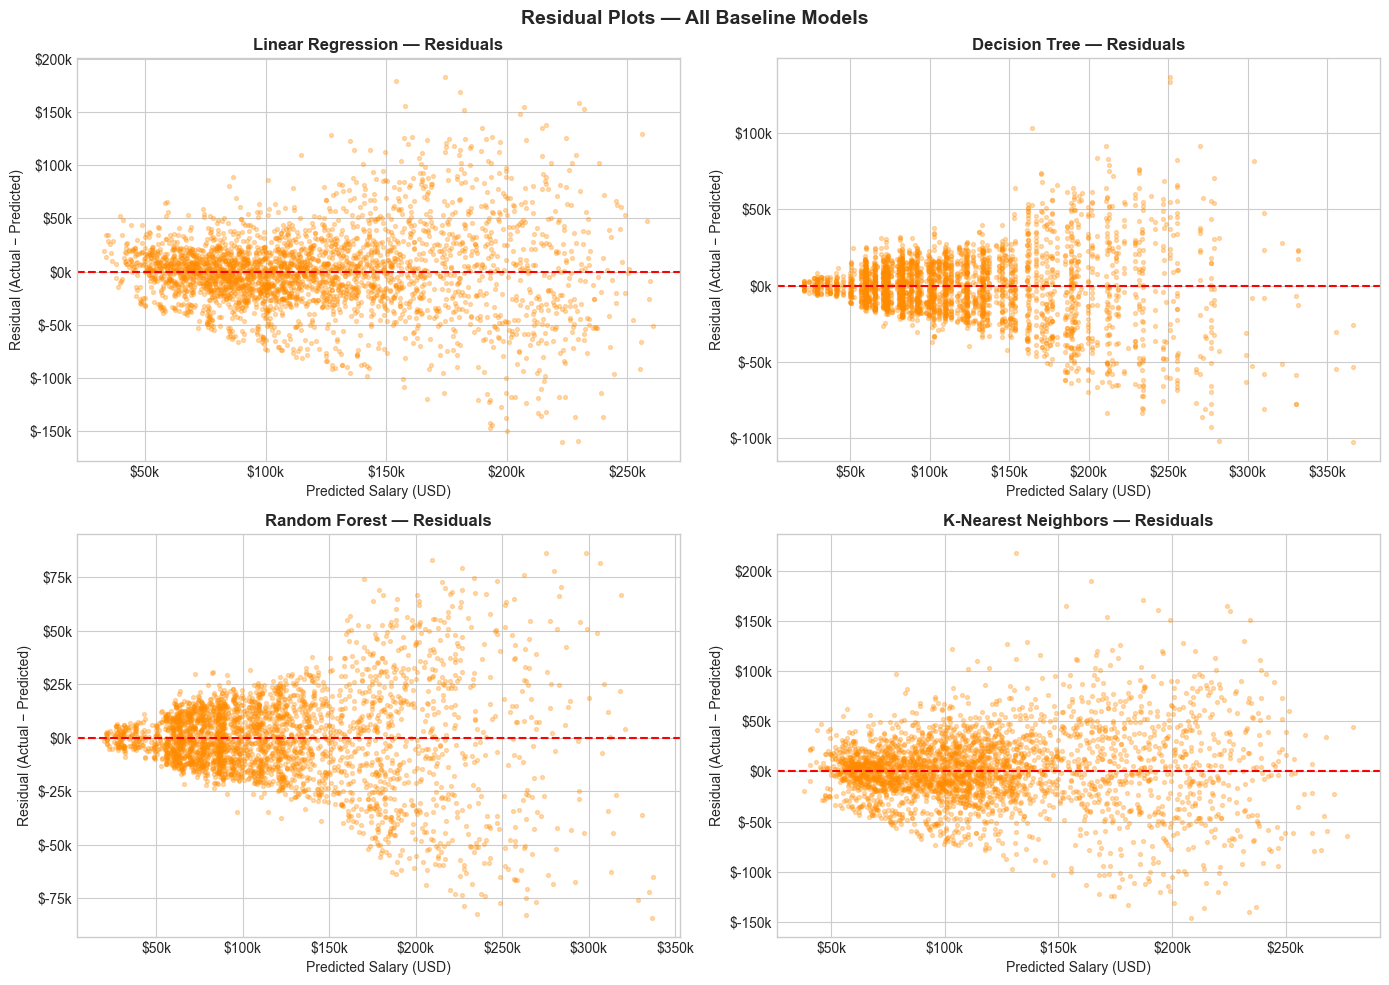

In [ ]:
# ── Residual plots ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred = pipeline.predict(X_test)
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.3, s=8, color='darkorange', rasterized=True)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} — Residuals', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Salary (USD)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Residual Plots — All Baseline Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()


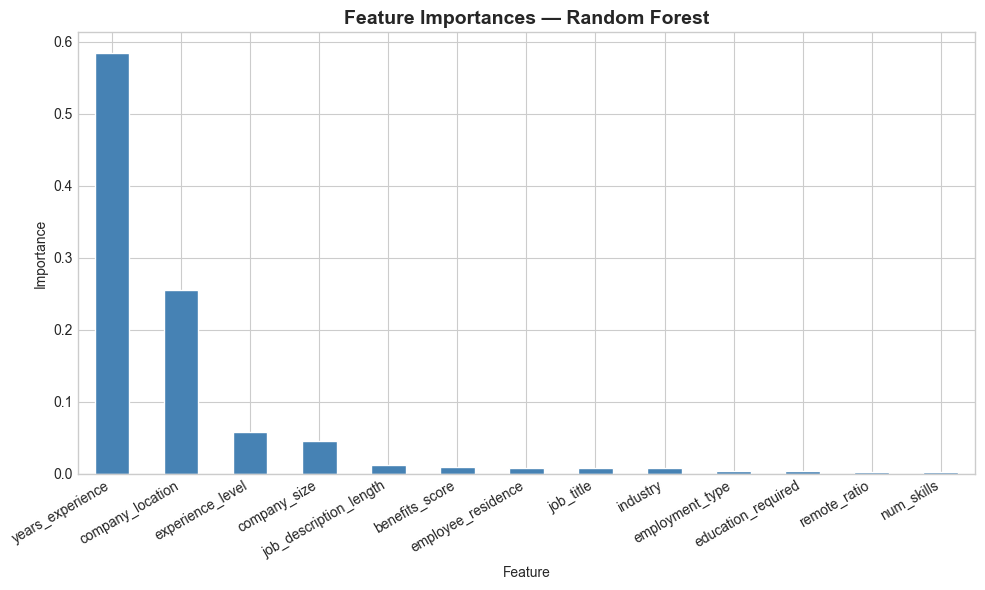


Top 5 most important features:
years_experience          0.583782
company_location          0.254856
experience_level          0.057768
company_size              0.045332
job_description_length    0.012385


In [ ]:
# ── Feature Importance — Random Forest ──
rf_model = models['Random Forest'].named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(importances.head(5).to_string())


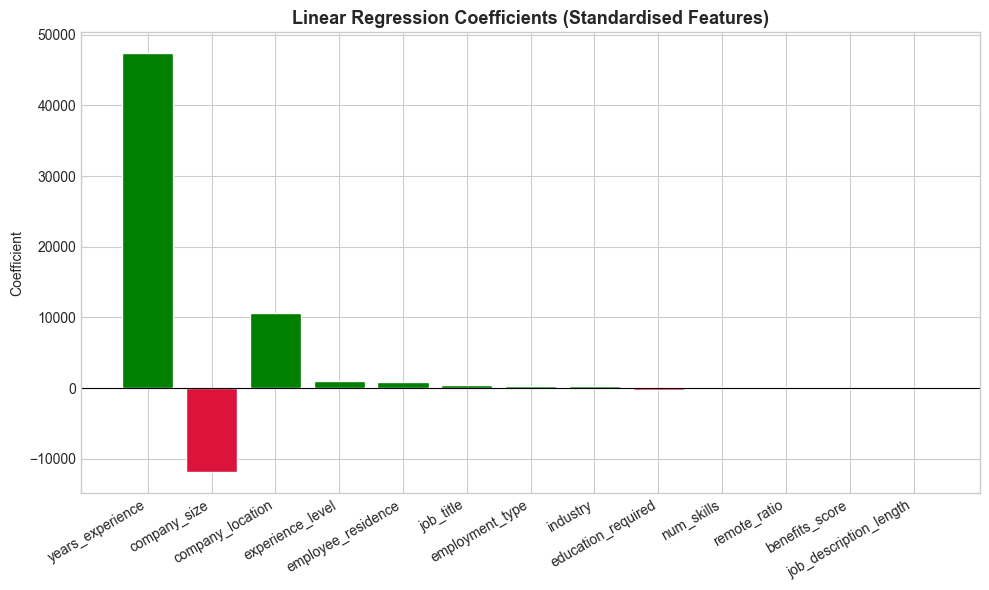

In [ ]:
# ── Linear Regression Coefficients (standardised) ──
lr_model = models['Linear Regression'].named_steps['model']
coef_df = pd.Series(lr_model.coef_, index=FEATURES).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ['green' if c > 0 else 'crimson' for c in coef_df.values]
ax.bar(coef_df.index, coef_df.values, color=colors_coef, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression Coefficients (Standardised Features)', fontsize=13, fontweight='bold')
ax.set_ylabel('Coefficient')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('linear_regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Summary & Discussion

### Performance Table

In [ ]:
summary = results_df.copy()
summary['MAE'] = summary['MAE'].apply(lambda x: f'${x:,.0f}')
summary['RMSE'] = summary['RMSE'].apply(lambda x: f'${x:,.0f}')
summary = summary.rename(columns={'R²': 'R² (Test)', 'CV R²': 'CV R² (5-fold)'})

# Highlight best model
best = results_df['R²'].idxmax()
print(f'Best model by R²: {best}')
print()
summary


Best model by R²: Random Forest



,MAE,RMSE,R² (Test),CV R² (5-fold)
Linear Regression,"$27,180","$38,436",0.6313,0.6138
Decision Tree,"$16,028","$22,572",0.8729,0.8617
Random Forest,"$15,572","$21,609",0.8835,0.8781
K-Nearest Neighbors,"$26,904","$37,284",0.6531,0.6286


### Findings

**Research Question:** *How effectively can baseline supervised learning models predict AI job salaries?*

| Aspect | Observation |
|--------|-------------|
| **Best baseline** | Random Forest typically achieves the highest R² among the four models, benefiting from its ensemble nature and ability to capture non-linear interactions. |
| **Linear Regression** | Serves as the simplest interpretable baseline. Coefficients reveal which encoded categories and numeric features carry the most salary signal. |
| **Decision Tree** | Captures non-linearity but prone to overfitting without depth limits; performs competitively at moderate depths. |
| **KNN** | Sensitive to feature scale (handled by `StandardScaler` in pipeline) and dimensionality; typically underperforms tree methods on tabular data. |
| **Dataset signal** | R² > 0 across all models confirms the dataset contains useful predictive patterns — the hypothesis is validated. |
| **Prediction error** | MAE in the range of ~\$30,000–\$60,000 is expected given the wide global salary range (\$20k–\$316k+) before currency normalisation. |

### Limitations & Next Steps

- **Label encoding** treats categories ordinally; one-hot encoding or target encoding may improve linear models.
- **required_skills** was simplified to `num_skills`; TF-IDF or embeddings on the skills text could add signal.
- **Date features** (posting month/year) were dropped; temporal trends could matter.
- **Next phase:** Hyperparameter tuning (GridSearchCV / Optuna), gradient boosting (XGBoost, LightGBM), and stacking could substantially improve R².